In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#load the dataset
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
#clean the data
df.columns = df.columns.str.strip()   # remove spaces
df['Date'] = pd.to_datetime(df['Date'])
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB
None
                                Date  Estimated Unemployment Rate (%)  \
count                            740                 

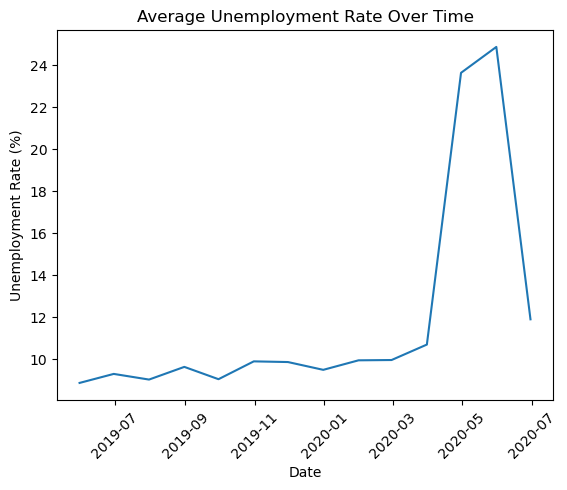

In [6]:
avg_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure()
plt.plot(avg_trend.index, avg_trend.values)
plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

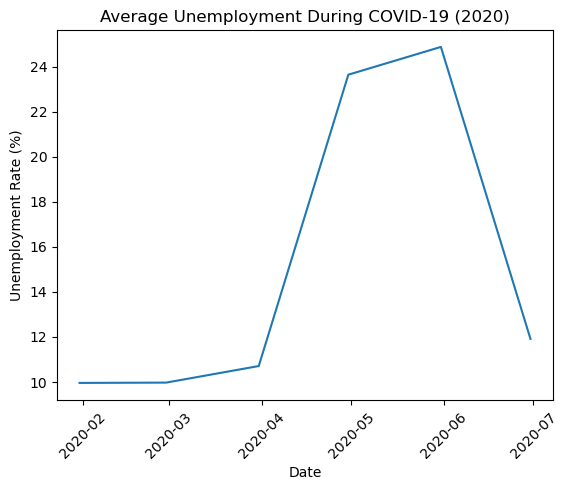

In [8]:
#COVID impact analysis
covid_data = df[df['Date'].dt.year == 2020]

covid_avg = covid_data.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure()
plt.plot(covid_avg.index, covid_avg.values)
plt.title("Average Unemployment During COVID-19 (2020)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

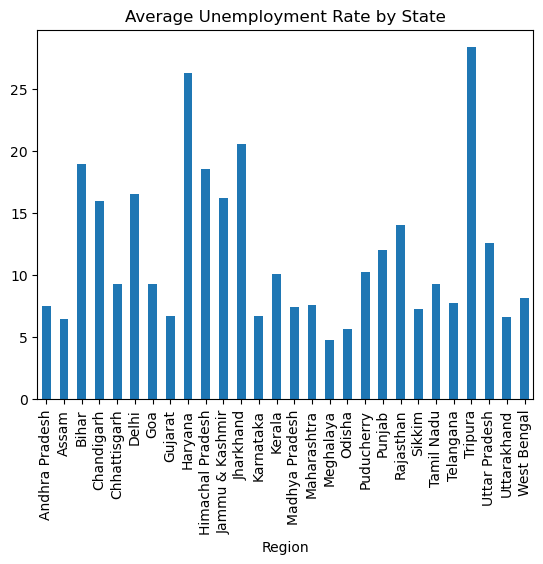

In [9]:
#state wise analysis
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

state_avg.plot(kind='bar')
plt.title("Average Unemployment Rate by State")
plt.xticks(rotation=90)
plt.show()

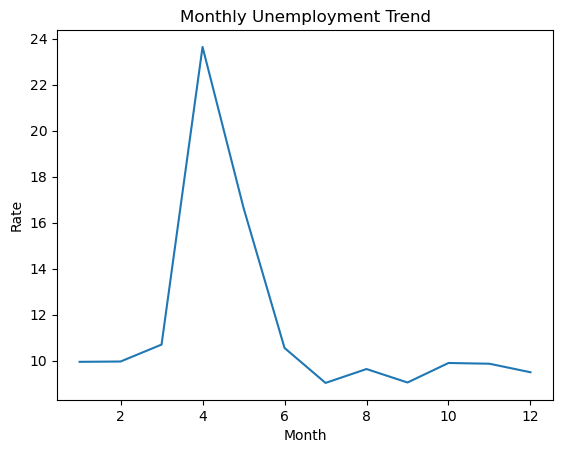

In [10]:
#Montly trend(seasonal pattern)
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg.plot()
plt.title("Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Rate")
plt.show()